In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt


In [13]:
#downloads the dataset of handwritten numbers from sklearn 
from torchvision import datasets
from sklearn.model_selection import train_test_split

dataset = datasets.MNIST(root = './data', train = True, download = True)

picture = dataset.data.numpy()
correct = dataset.targets.numpy()

#flattening pictures into 1d to make it simpler
good_pictures = picture.reshape(picture.shape[0],-1)
good_pictures = good_pictures/255.0

#splitting the dataset into test and train

picture_train, picture_test, correct_train, correct_test = train_test_split(good_pictures, correct, test_size = 0.2, random_state=42)

print(picture_train.shape)
print(picture_test.shape)


100.0%
100.0%
100.0%
100.0%


(48000, 784)
(12000, 784)


In [14]:
#convert numpy array to pytorch tensors

x_train = torch.from_numpy(picture_train).float()
x_test = torch.from_numpy(picture_test).float()
y_train = torch.from_numpy(correct_train).long()
y_test = torch.from_numpy(correct_test).long()


print(x_train[0])

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

In [15]:
#create dataloader and dataset
from torch.utils.data import Dataset, DataLoader

#the dataset
class data(Dataset):
    def __init__ (self, x, y): 
        self.x = x
        self.y = y

    def __len__(self): #special "dunder method", when you call len(data) later, it automatically uses this function. dont use data.len() thanks to dunder
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx] #also special, no need to specify method later, just dataset[the index

#wrapping the dataset in dataloader
training_dataset = data(x_train, y_train)
testing_dataset = data(x_test, y_test)
training_data = DataLoader(training_dataset, batch_size = 32, shuffle=True)
testing_data = DataLoader(testing_dataset, batch_size = 32, shuffle = False) #the __getitem__ and __len__ functions are used by the dataloader internally so it knows how to grab items, batch size, etc. They are needed for every dataset 


In [16]:
#the neural network
import torch.nn as nn
class numbers(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear1=nn.Linear(784, 128)
        self.relu1 = nn.ReLU()
        self.linear2 = nn.Linear(128,64)
        self.relu2 = nn.ReLU()
        self.linear3 = nn.Linear(64, 19)
    def forward(self, x):
        x = self.linear1(x)
        x=self.relu1(x)
        x=self.linear2(x)
        x=self.relu2(x)
        x=self.linear3(x)
        return  x

In [17]:
import torch.optim as optim

#training loop
epochs = 5
model = numbers()
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)

loss_over_time = []

for epoch in range(epochs):
    total_loss_per_epoch = 0
    batch = 0
    for x,y in training_data: #takes one batch at a time (32 samples), no additional for loop is needed due to Pytorch's inbuild functions? 
        #1. forward pass
        output = model(x)
        #2. calculate loss
        loss = loss_function(output, y) #this calculates the avarege loss for one batch
        #3. Optimizer zero grad
        optimizer.zero_grad()
        #4. loss backwards
        loss.backward()
        #5. optimizer step
        optimizer.step()

        total_loss_per_epoch += loss.item() #item() converts a python tensor with one number to a regular python number
        batch += 1
    loss_over_time.append(total_loss_per_epoch/batch)

In [18]:
#evaluating the model
model.eval()

with torch.no_grad():
    total_correct = 0
    total_test_samples = 0
    for xtest, ytest in testing_data:
        predictions = model(xtest)
        testloss = loss_function(predictions, ytest)

        predicted = torch.max(predictions,1)#go find the most likely number
        #the model processes 32 pictures at once, and each of them gets a 1 dimension tensor. 
        #(predictions, 1) is needed to take the highest value(most likely number) for all 32 pictures in the batch

        correct_per_batch = (predicted[1]==ytest).sum().item()
        total_correct += correct_per_batch
        total_test_samples += ytest.size(0)


    accuracy = total_correct/total_test_samples


print(accuracy)

0.9600833333333333


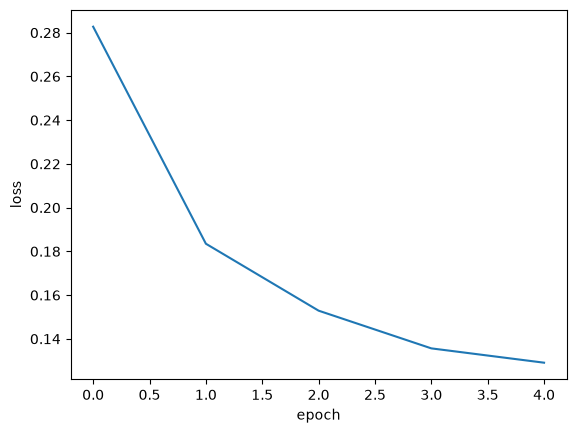

In [19]:
#plotting loss
import matplotlib.pyplot as plt

plt.plot(loss_over_time)
plt.xlabel ("epoch") 
plt.ylabel ("loss")
plt.show()

In [20]:
#saving the model
torch.save(model, "realmodel.pth")

#use model = torch.load("model.pth") to load